## PRT564 — Data Analytics & Visualisation
### Regression Analysis

In [1]:
import os

BASE = r"C:\Users\ranas\OneDrive\Desktop\Rana_Research_Workspace\Rana_Research_Workspace"
CLEAN   = os.path.join(BASE, "Clean_Dataset")
REG_OUT = os.path.join(BASE, "Regression_Outputs")
os.makedirs(REG_OUT, exist_ok=True)

for p, n in [(CLEAN,"Clean_Dataset"),(REG_OUT,"Regression_Outputs")]:
    print(n, "found" if os.path.exists(p) else "NOT FOUND")

Clean_Dataset found
Regression_Outputs found


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.05)
print("ready")

ready


In [3]:
df = pd.read_csv(os.path.join(CLEAN, 'clean_dataset.csv'), parse_dates=['quarter'])
df = df.sort_values('quarter').reset_index(drop=True)

# create weighted avg features (not in preprocessing notebook)
df['RPPI_Weighted_Avg_lag1'] = df['RPPI_Weighted_Avg'].shift(1)
df['RPPI_Weighted_Avg_YoY']  = df['RPPI_Weighted_Avg'].pct_change(4) * 100
df['logRPPI_Weighted_Avg']   = np.log(df['RPPI_Weighted_Avg'])

print(f"{len(df)} rows x {df.shape[1]} columns")
print(df[['quarter','RPPI_Weighted_Avg','RPPI_Weighted_Avg_lag1']].tail(3).to_string(index=False))

74 rows x 157 columns
   quarter  RPPI_Weighted_Avg  RPPI_Weighted_Avg_lag1
2021-06-01              167.2                   156.7
2021-09-01              175.6                   167.2
2021-12-01              183.9                   175.6


In [4]:
TARGET = 'RPPI_Weighted_Avg'

FEATURES = [
    'RPPI_Weighted_Avg_lag1',
    'EHPI_Weighted_Avg',
    'ADPI_Weighted_Avg',
    'MeanDP_Australia',
    'Transfers_Sydney',
    'Transfers_Melbourne',
    'time_idx',
    'RPPI_Weighted_Avg_YoY',
]

model_df = df[['quarter', TARGET] + FEATURES].dropna().reset_index(drop=True)
X = model_df[FEATURES].values
y = model_df[TARGET].values
quarters = model_df['quarter']

# chronological split — random split would leak future data into training
split = int(len(model_df) * 0.80)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
q_train, q_test = quarters[:split], quarters[split:]

print(f"train: {len(X_train)} quarters ({q_train.iloc[0].date()} to {q_train.iloc[-1].date()})")
print(f"test:  {len(X_test)} quarters ({q_test.iloc[0].date()} to {q_test.iloc[-1].date()})")

train: 56 quarters (2004-09-01 to 2018-06-01)
test:  14 quarters (2018-09-01 to 2021-12-01)


In [5]:
def evaluate(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"  {label}: MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}")
    return mae, rmse, r2

In [6]:
# Model 1 — OLS baseline (no regularisation)
ols = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])
ols.fit(X_train, y_train)

y_train_ols = ols.predict(X_train)
y_test_ols  = ols.predict(X_test)

print("OLS")
tr_mae, tr_rmse, tr_r2 = evaluate(y_train, y_train_ols, "train")
te_mae, te_rmse, te_r2 = evaluate(y_test,  y_test_ols,  "test")
cv = cross_val_score(ols, X_train, y_train, cv=5, scoring='r2')
print(f"  cv R²: {cv.mean():.4f} ± {cv.std():.4f}")

results = {'OLS': {'train_mae':tr_mae,'train_rmse':tr_rmse,'train_r2':tr_r2,
                   'test_mae':te_mae,'test_rmse':te_rmse,'test_r2':te_r2,
                   'cv_mean':cv.mean(),'cv_std':cv.std(),'y_pred':y_test_ols}}

OLS
  train: MAE=0.0353  RMSE=0.0428  R²=1.0000
  test: MAE=0.2423  RMSE=0.4136  R²=0.9992
  cv R²: 0.9995 ± 0.0004


In [7]:
# Model 2 — Ridge (L2 regularisation)
alphas = [0.01, 0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000]
ridge_cv = Pipeline([('scaler', StandardScaler()), ('model', RidgeCV(alphas=alphas, cv=5))])
ridge_cv.fit(X_train, y_train)
best_alpha_r = ridge_cv.named_steps['model'].alpha_

ridge = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=best_alpha_r))])
ridge.fit(X_train, y_train)

y_train_r = ridge.predict(X_train)
y_test_r  = ridge.predict(X_test)

print(f"Ridge (alpha={best_alpha_r})")
tr_mae, tr_rmse, tr_r2 = evaluate(y_train, y_train_r, "train")
te_mae, te_rmse, te_r2 = evaluate(y_test,  y_test_r,  "test")
cv = cross_val_score(ridge, X_train, y_train, cv=5, scoring='r2')
print(f"  cv R²: {cv.mean():.4f} ± {cv.std():.4f}")
print(f"  coefficients: {dict(zip(FEATURES, ridge.named_steps['model'].coef_.round(4)))}")

results['Ridge'] = {'train_mae':tr_mae,'train_rmse':tr_rmse,'train_r2':tr_r2,
                    'test_mae':te_mae,'test_rmse':te_rmse,'test_r2':te_r2,
                    'cv_mean':cv.mean(),'cv_std':cv.std(),'best_alpha':best_alpha_r,'y_pred':y_test_r}

Ridge (alpha=0.01)
  train: MAE=0.0624  RMSE=0.0756  R²=1.0000
  test: MAE=0.3164  RMSE=0.4725  R²=0.9990
  cv R²: 0.9960 ± 0.0045
  coefficients: {'RPPI_Weighted_Avg_lag1': np.float64(0.8953), 'EHPI_Weighted_Avg': np.float64(16.9301), 'ADPI_Weighted_Avg': np.float64(5.0297), 'MeanDP_Australia': np.float64(0.0442), 'Transfers_Sydney': np.float64(0.0177), 'Transfers_Melbourne': np.float64(0.0019), 'time_idx': np.float64(0.1066), 'RPPI_Weighted_Avg_YoY': np.float64(0.0593)}


In [8]:
# Model 3 — Lasso (L1 regularisation, can zero out features)
lasso_cv = Pipeline([('scaler', StandardScaler()),
                     ('model', LassoCV(alphas=[0.001,0.005,0.01,0.05,0.1,0.5,1,5,10], cv=5, max_iter=10000))])
lasso_cv.fit(X_train, y_train)
best_alpha_l = lasso_cv.named_steps['model'].alpha_

lasso = Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=best_alpha_l, max_iter=10000))])
lasso.fit(X_train, y_train)

y_train_l = lasso.predict(X_train)
y_test_l  = lasso.predict(X_test)

print(f"Lasso (alpha={best_alpha_l})")
tr_mae, tr_rmse, tr_r2 = evaluate(y_train, y_train_l, "train")
te_mae, te_rmse, te_r2 = evaluate(y_test,  y_test_l,  "test")
cv = cross_val_score(lasso, X_train, y_train, cv=5, scoring='r2')
print(f"  cv R²: {cv.mean():.4f} ± {cv.std():.4f}")
coefs = lasso.named_steps['model'].coef_
for f, c in zip(FEATURES, coefs):
    note = " ← zeroed" if c == 0 else ""
    print(f"  {f}: {c:.4f}{note}")

results['Lasso'] = {'train_mae':tr_mae,'train_rmse':tr_rmse,'train_r2':tr_r2,
                    'test_mae':te_mae,'test_rmse':te_rmse,'test_r2':te_r2,
                    'cv_mean':cv.mean(),'cv_std':cv.std(),'best_alpha':best_alpha_l,'y_pred':y_test_l}

Lasso (alpha=0.001)
  train: MAE=0.0439  RMSE=0.0521  R²=1.0000
  test: MAE=0.2419  RMSE=0.4024  R²=0.9992
  cv R²: 0.9993 ± 0.0009
  RPPI_Weighted_Avg_lag1: 0.4337
  EHPI_Weighted_Avg: 17.8034
  ADPI_Weighted_Avg: 4.7429
  MeanDP_Australia: -0.0452
  Transfers_Sydney: 0.0142
  Transfers_Melbourne: -0.0019
  time_idx: 0.0693
  RPPI_Weighted_Avg_YoY: 0.0226


In [9]:
print(f"Metric                      OLS      Ridge      Lasso")
print("-"*52)
for label, key in [('Test MAE','test_mae'),('Test RMSE','test_rmse'),
                   ('Test R²','test_r2'),('CV Mean R²','cv_mean'),('CV Std R²','cv_std')]:
    print(f"  {label:<18} {results['OLS'][key]:>10.4f} {results['Ridge'][key]:>10.4f} {results['Lasso'][key]:>10.4f}")

winner = min(['OLS','Ridge','Lasso'], key=lambda m: results[m]['test_rmse'])
print(f"\nwinner by test RMSE: {winner} ({results[winner]['test_rmse']:.4f})")

Metric                      OLS      Ridge      Lasso
----------------------------------------------------
  Test MAE               0.2423     0.3164     0.2419
  Test RMSE              0.4136     0.4725     0.4024
  Test R²                0.9992     0.9990     0.9992
  CV Mean R²             0.9995     0.9960     0.9993
  CV Std R²              0.0004     0.0045     0.0009

winner by test RMSE: Lasso (0.4024)


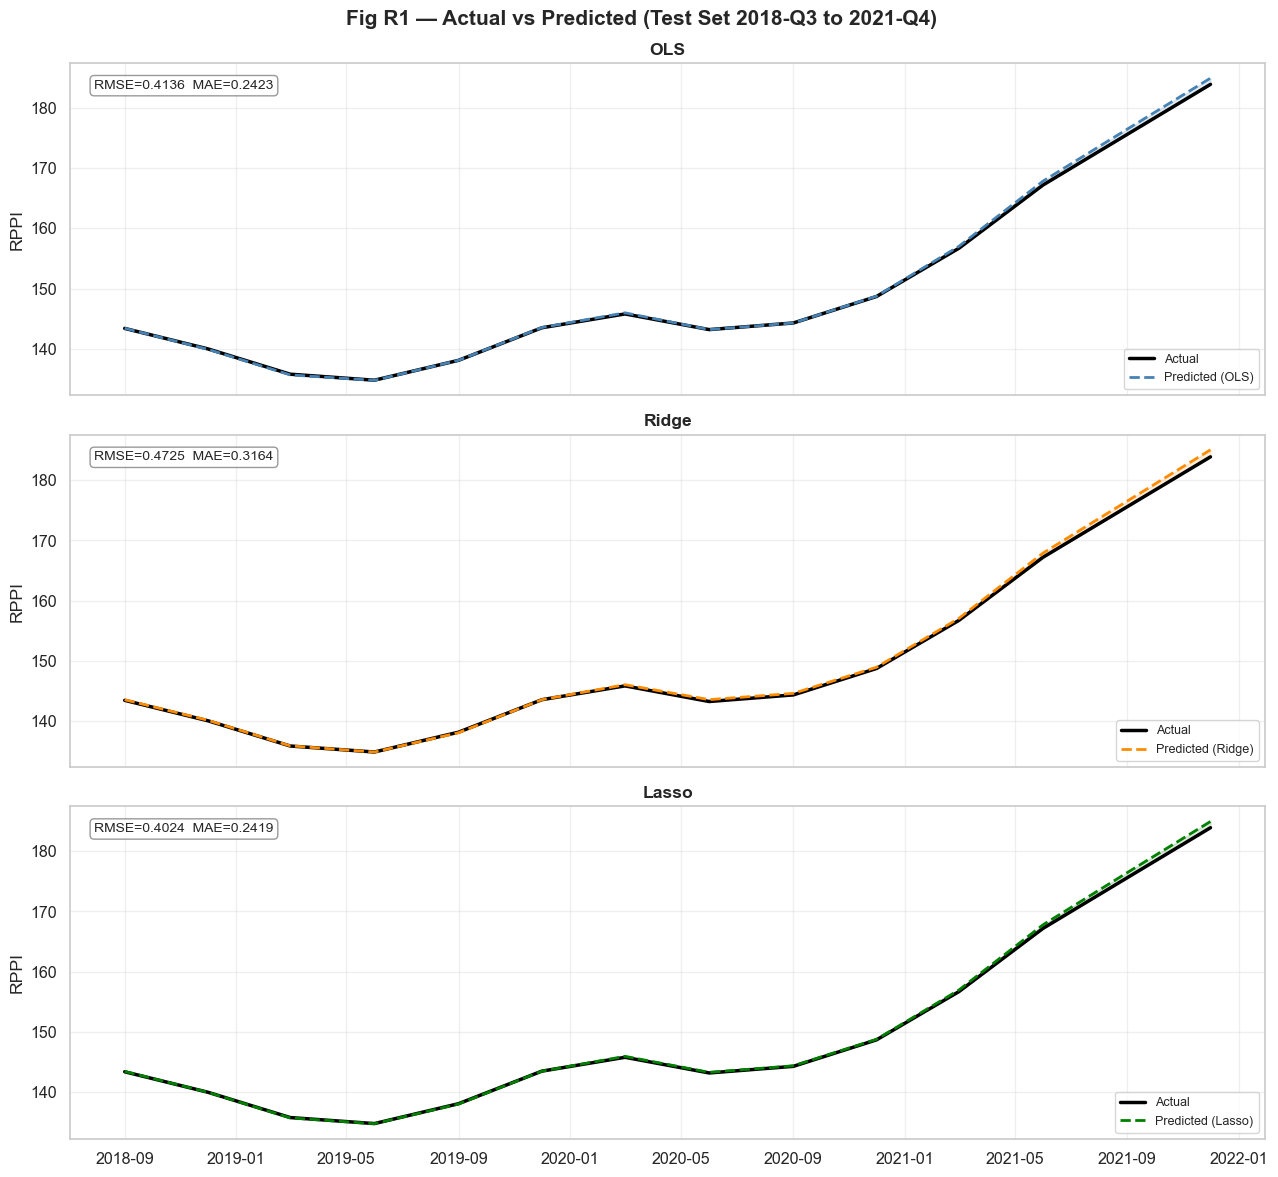

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True)
model_list = [('OLS',results['OLS']['y_pred'],'steelblue'),
              ('Ridge',results['Ridge']['y_pred'],'darkorange'),
              ('Lasso',results['Lasso']['y_pred'],'green')]

for ax, (name, y_pred, color) in zip(axes, model_list):
    ax.plot(q_test.values, y_test, color='black', lw=2.5, label='Actual')
    ax.plot(q_test.values, y_pred, color=color, lw=2, ls='--', label=f'Predicted ({name})')
    ax.fill_between(q_test.values, y_test, y_pred, alpha=0.15, color=color)
    rmse, mae = results[name]['test_rmse'], results[name]['test_mae']
    ax.text(0.02, 0.95, f'RMSE={rmse:.4f}  MAE={mae:.4f}', transform=ax.transAxes,
            fontsize=10, va='top', bbox=dict(boxstyle='round', facecolor='white', edgecolor='grey', alpha=0.8))
    ax.set_title(name, fontweight='bold'); ax.set_ylabel('RPPI'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

fig.suptitle('Fig R1 — Actual vs Predicted (Test Set 2018-Q3 to 2021-Q4)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REG_OUT, 'figR1_actual_vs_predicted.png'), dpi=150, bbox_inches='tight')
plt.show()

In [11]:
results_df = pd.DataFrame({
    'Model': ['OLS','Ridge','Lasso'],
    'Train_MAE':  [results[m]['train_mae']  for m in ['OLS','Ridge','Lasso']],
    'Train_RMSE': [results[m]['train_rmse'] for m in ['OLS','Ridge','Lasso']],
    'Train_R2':   [results[m]['train_r2']   for m in ['OLS','Ridge','Lasso']],
    'Test_MAE':   [results[m]['test_mae']   for m in ['OLS','Ridge','Lasso']],
    'Test_RMSE':  [results[m]['test_rmse']  for m in ['OLS','Ridge','Lasso']],
    'Test_R2':    [results[m]['test_r2']    for m in ['OLS','Ridge','Lasso']],
    'CV_Mean_R2': [results[m]['cv_mean']    for m in ['OLS','Ridge','Lasso']],
    'CV_Std_R2':  [results[m]['cv_std']     for m in ['OLS','Ridge','Lasso']],
})
results_df.to_csv(os.path.join(REG_OUT, 'model_results.csv'), index=False)

preds_df = pd.DataFrame({
    'quarter': q_test.values, 'actual': y_test,
    'pred_ols': results['OLS']['y_pred'], 'pred_ridge': results['Ridge']['y_pred'],
    'pred_lasso': results['Lasso']['y_pred'],
    'resid_ols':   y_test - results['OLS']['y_pred'],
    'resid_ridge': y_test - results['Ridge']['y_pred'],
    'resid_lasso': y_test - results['Lasso']['y_pred'],
})
preds_df.to_csv(os.path.join(REG_OUT, 'model_predictions.csv'), index=False)
print("saved model_results.csv and model_predictions.csv")

saved model_results.csv and model_predictions.csv
